In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.interpolate import interp1d


In [2]:
## Define linear e.o.s.
def rho_eq(S, T):
    return 1000 + S * (0.7718) - T * (0.17765) 

In [501]:
def entrainment(z, ui_interp, uo_interp, bi_interp, bo_interp, rho_a, rho_i_interp, rho_r):

    c1 = -1.0
    eps = 0.015
    u_s = 0.1
    alpha_a = 0.110
    alpha_o = 0.110
    alpha_i = 0.02

    if isinstance(bo_interp, np.ndarray) or isinstance(bo_interp, numbers.Number):
        u_i = ui_interp
        u_o = uo_interp
        b_i = bi_interp
        b_o = bo_interp
        rho_i = rho_i_interp
        E_i = 0.2

    else:
        u_i = ui_interp(z)
        u_o = uo_interp(z)
        b_i = bi_interp(z)
        b_o = bo_interp(z)
        rho_i = rho_i_interp(z)
        E_i = 0.2* np.ones(len(u_i))


    # entrainment fluxes (volumetric: m^3/s per unit length)
     #2.0 * math.pi * b_i * alpha_i * (abs(u_i) + c1 * abs(u_o))

    # E_o/E_a should be zero if u_o == 0, otherwise remove mass from inner if outer pulls
    # if abs(u_o) < 1e-12:
    #     E_o = 0.0
    #     E_a = 0.0
    # else:
    E_o = 2.0 * math.pi * b_i * alpha_o * abs(u_o)
    E_a = 2.0 * math.pi * b_o * alpha_a * abs(u_o)

    # plume production / detrainment (make sign remove mass if positive)
    # ensure no division by zero in u_i
    E_p = -eps * (u_s / u_i)**2 * 9.81 * (rho_a - rho_i) / rho_r * math.pi * b_i**2 / u_i

    return E_i, E_o, E_a, E_p


In [238]:
def inner_plume(z, y, Q_o, M_o, T_o, S_o):

    Q_i = y[0]
    M_i = y[1]
    T_tot = y[2]
    S_tot = y[3]

    T_i = T_tot / Q_i    # concentration (°C)
    S_i = S_tot / Q_i    # concentration (PSU)

    # velocities and width
    u_i = M_i / Q_i

    if Q_o == 0:
        u_o = 0.0
        b_o = 0.0
    else:
        u_o = M_o / Q_o
        b_o = (Q_o**2/(math.pi * M_o) + (Q_i/np.sqrt(math.pi*M_i))**2 )**0.5

    b_i = Q_i / np.sqrt(math.pi * M_i)  # protect sqrt arg

    # densities (ensure rho_eq expects PSU, degC)
    rho_i = rho_eq(S_i, T_i)

    # parameters (as in your code)
    chi = 0.0001
    rho_b = 1.204
    rho_a = rho_eq(34,2)
    rho_r = 1024.
    rho_m = chi * rho_b + (1-chi) * rho_i

    E_i, E_o, E_a, E_p = entrainment(u_i, u_o, b_i, b_o, rho_a, rho_m, rho_r)
    
    gamma = 1.1
    lam = 1.0
    g = 9.81
    
    # Buoyancy production term used in momentum eqn
    g_flux = math.pi * g * b_i**2 * (lam**2 * (rho_a - rho_m)) / (gamma * rho_r)

    # mass (Q) and momentum (M) tendencies
    dQidz = E_i - E_o - E_p
    dMidz = g_flux + E_i * u_o - E_o * u_i - E_p * u_i

    # Conservative salt & heat evolution: d(Q*S)/dz = E_i*S_o - E_o*S_i - E_p*S_i
    dS_tot_dz = E_i * S_o - E_o * S_i - E_p * S_i
    dT_tot_dz = E_i * T_o - E_o * T_i - E_p * T_i

    return np.array([dQidz, dMidz, dT_tot_dz, dS_tot_dz])

Initial Vol. Flux = 314.1592653589793. Initial Mom. Flux = 314.1592653589793.


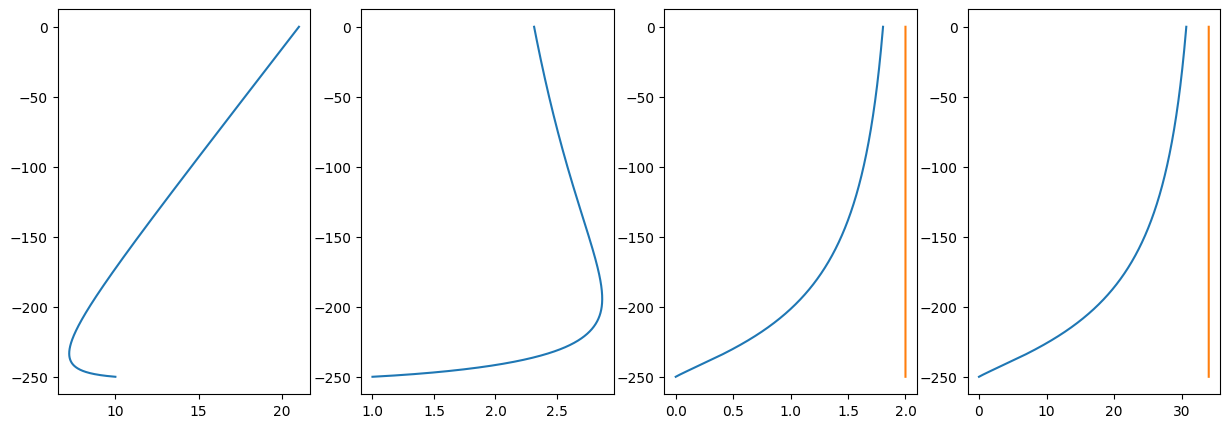

In [239]:
z_span = np.array([-250,0])
dz = 0.1
zLevels = np.arange(z_span[0], z_span[-1], dz)
Nz = len(zLevels)

bi_i = 10
ui_i = 1

Qi_i = bi_i**2 * ui_i * math.pi 
Mi_i = bi_i**2 * ui_i**2 * math.pi 
print(f"Initial Vol. Flux = {Qi_i}. Initial Mom. Flux = {Mi_i}.")
Ti_i = 0
Si_i = 0

Ttot_i = Ti_i * Qi_i
Stot_i = Si_i * Qi_i

y0_inner = np.array([Qi_i, Mi_i, Ttot_i, Stot_i])
T_a = 2
S_a = 34
sol = solve_ivp(inner_plume, z_span, y0_inner, t_eval = zLevels, args=(0,0,T_a,S_a))

sol_outer = solve_ivp(
    inner_plume,
    (-250,0),  # backward in z
    y0_inner,
    method='RK45',
    max_step=1.0,
    args=(0,0,T_a,S_a),
    dense_output=True
)

Qi = sol.y[0]
Mi = sol.y[1]
Ti = sol.y[2] / Qi
Si = sol.y[3] / Qi
bi = Qi/np.sqrt(np.pi * Mi)
ui = Mi/Qi
z = sol.t

fig, ax = plt.subplots(1,4, figsize = (15,5))

ax[0].plot(Qi/np.sqrt(np.pi * Mi), z)
ax[1].plot(Mi/Qi, z)
ax[2].plot(Ti, z)
ax[2].plot(np.ones(Nz) * T_a,z)
ax[3].plot(Si, z)
ax[3].plot(np.ones(Nz) * S_a, z)



In [ ]:
## May be irrelevant
def outer_plume(t, y, Q_i, M_i, T_i, S_i):

    Q_o = y[0]
    M_o = y[1]
    T_tot = y[2]
    S_tot = y[3]

    T_o = T_tot / Q_o    # concentration (°C)
    S_o = S_tot / Q_o    # concentration (PSU)

    b_i = Q_i / np.sqrt(math.pi * M_i)
    u_i = M_i / Q_i

    if Q_o == 0:
        u_o = 0
        b_o = 0
    else:
        u_o = M_o / Q_o
        b_o = (Q_o**2/(math.pi * M_o) + b_i**2)**(1/2)

    chi = 0.1
    T_a = 2
    S_a = 34
    rho_i = 1000
    rho_b = 1.204
    rho_a = rho_eq(34, 2)
    rho_r = 1024
    rho_o = 1010
    rho_m = chi * rho_b + (1-chi) * rho_i
    cp = 4019
    c1 = 1
    c2 = 1
    eps = 0.015
    u_s = 0.1
    alpha_a = 0.110
    alpha_o = 0.110
    alpha_i = 0.055
    gamma = 1.1
    gamma_o = 1.1

    B_i = 9.81 * (rho_a - rho_i)/(rho_r) * math.pi * b_i**2 * u_i

    E_i = 2 * math.pi * b_i * alpha_i * (u_i + c1 * u_o)

    if u_o == 0:
        E_o = 0
        E_a = 0
    else:
        E_o = -2 * math.pi * b_i * alpha_o * u_o
        E_a = -2 * math.pi * b_o * alpha_a * u_o

    E_p = -c2 * eps * (u_s / u_i)**2 * (B_i / u_i**2)

    g_flux =  math.pi * 9.81 * (b_o**2 - b_i**2) * (rho_o - rho_a) / (gamma_o * rho_r)

    dQo_dz = E_a + E_o - E_i + E_p

    dMo_dz = g_flux + E_i * u_o - E_o * u_i - E_p * u_i

    dTot_dz = E_i * T_o - E_o * T_i - E_a * T_a - E_p * T_i

    dSot_dz = E_i * S_o - E_o * S_i - E_a * S_a - E_p * S_i

    return np.array([dQo_dz, dMo_dz, dTot_dz, dSot_dz])

In [300]:
## Equation 16 and 17 from Socolofsky et al 2008 to get u_o initial
def uo_init(u_o, Q_o, rho_o, b_i):

    F_o = 0.1
    rho_a = rho_eq(34, 2)
    
    g_prime = 9.81 * (rho_a - rho_o) / rho_o

    func = u_o / (np.sqrt( (np.sqrt(Q_o**2  / (math.pi * Q_o * u_o + b_i**2)) - b_i) * g_prime)) - F_o

    return func

a = 0
b = 0.5

print(f"f({a}) = {outer_init(a, Qi[-1], rho_eq(Si[-1],Ti[-1]), bi[-1])}")
print(f"f({b}) = {outer_init(b, Qi[-1], rho_eq(Si[-1],Ti[-1]), bi[-1])}")

root = brentq(uo_init, a, b, args = (1.1 *Qi[-1], rho_eq(Si[-1],Ti[-1]), bi[-1]))

print(f"\nThe root found by brentq is: {root}")
print(f"Value of the function at the root: {outer_init(root, Qi[-1], rho_eq(Si[-1],Ti[-1]), bi[-1])}")

f(0) = -0.1
f(0.5) = 3.9183434202817335

The root found by brentq is: 0.12278714243983464
Value of the function at the root: 0.5211647636466001


In [284]:

# === Step 1: Assume these come from your inner plume solver ===
# z_inner goes from -250 (deep) to 0 (surface)
# Qi, Mi, Ti, Si are the inner plume discharge, momentum, temperature, salinity
# Example placeholders:
# z_inner = np.linspace(-250, 0, 200)
# Qi, Mi, Ti, Si = inner_plume_solver(...)
# Replace the above with your actual inner plume arrays
Ei, Eo, Ea, Ep = entrainment(ui, uo, bi, bo, rho_a, rho_i, rho_r)
z = np.arange(-250,0,dz)
# === Step 2: Interpolators for inner plume variables ===
Qi_interp = interp1d(z, Qi, fill_value="extrapolate")
Mi_interp = interp1d(z, Mi, fill_value="extrapolate")
Ti_interp = interp1d(z, Ti, fill_value="extrapolate")
Si_interp = interp1d(z, Si, fill_value="extrapolate")

# Ea_interp = interp1d(z, Ea, fill_value="extrapolate")
Ep_interp = interp1d(z, Ep, fill_value="extrapolate")
# Eo_interp = interp1d(z, Eo, fill_value="extrapolate")
Ei_interp = interp1d(z, Ei, fill_value="extrapolate")

# === Step 3: Outer plume ODE system ===
def outer_plume(z, y):
    """
    Outer plume ODE system integrated from z=0 downward.
    y = [Q_o, M_o, T_tot, S_tot]
    """
    Q_o, M_o, T_tot, S_tot = y

    S_o = S_tot / Q_o
    T_o = T_tot / Q_o

    # Inner plume values at this z
    Q_i = Qi_interp(z)
    M_i = Mi_interp(z)
    T_i = Ti_interp(z)
    S_i = Si_interp(z)

    E_i = Ei_interp(z)
    E_o = 0 #Eo_interp(z)
    E_a = 0 #Ea_interp(z)
    E_p = Ep_interp(z)

    # Example constants (replace with your actual ones)
    g = 9.81
    rho_o = rho_eq(S_o, T_o)
    rho_a = rho_eq(34,2)  # ambient density
    b_i = np.sqrt(M_i / (np.pi * Q_i))  # example formula, replace if needed
    b_o = np.sqrt(M_o / (np.pi * Q_o) + b_i**2)

    # Example velocities
    u_o = M_o / Q_o
    u_i = M_i / Q_i

    g_flux =  math.pi * 9.81 * (b_o**2 - b_i**2) * (rho_o - rho_a) / (1.1 * 1024)

    # Physics here: replace with your real outer plume equations
    dQo_dz = E_a + E_o - E_i + E_p   # placeholder entrainment/detrainment
    dMo_dz = g_flux + E_i * u_o - E_o * u_i - E_p * u_i   # placeholder
    dTot_dz = E_i * T_o - E_o * T_i - E_a * T_a - E_p * T_i          # placeholder for heat content change
    dSot_dz = E_i * S_o - E_o * S_i - E_a * S_a - E_p * S_i          # placeholder for salt content change


    return np.array([dQo_dz, dMo_dz, dTot_dz, dSot_dz])

# === Step 4: Initial conditions at z=0 ===
# You get u_o from your root-finding step
u_o_init = 0.5  # example
b_i0 = np.sqrt(Mi_interp(0) / (np.pi * Qi_interp(0)))
b_o0 = np.sqrt(Qi_interp(0) / (np.pi * u_o_init) + b_i0**2)

Q_o_init = np.pi * b_o0**2 * u_o_init
M_o_init = Q_o_init * u_o_init
T_o_init = Ti_interp(0)  # example, maybe ambient at surface
S_o_init = Si_interp(0)

# Convert to transported properties
T_tot_init = Q_o_init * T_o_init
S_tot_init = Q_o_init * S_o_init

y0_outer = [Q_o_init, M_o_init, T_tot_init, S_tot_init]

# === Step 5: Integrate outer plume from z=0 to z=-250 ===
sol_outer = solve_ivp(
    outer_plume,
    (0.0, -250.0),  # backward in z
    y0_outer,
    method='RK45',
    max_step=1.0,
    dense_output=True
)

# === Step 6: Access results ===
z_outer = sol_outer.t
Q_o = sol_outer.y[0]
M_o = sol_outer.y[1]
T_tot = sol_outer.y[2]
S_tot = sol_outer.y[3]

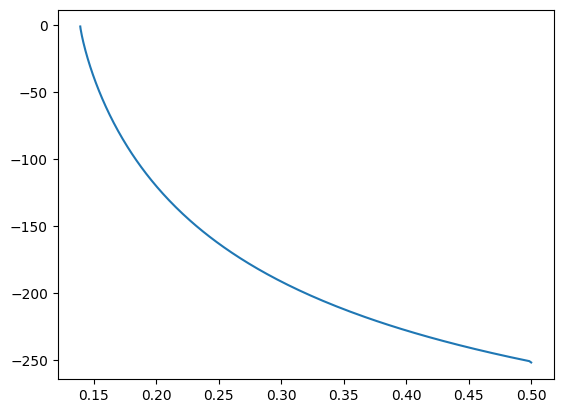

In [285]:
plt.plot(M_o/Q_o, np.arange(-252, 0, 1))

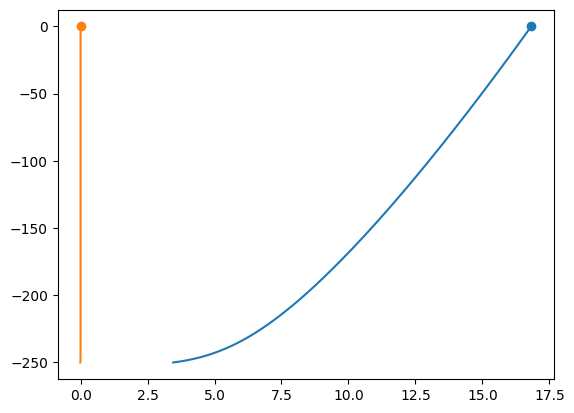

In [240]:
chi = 0.0001
rho_b = 1.204
rho_a = rho_eq(34, 2)
rho_r = 1024.
rho_i = rho_eq(Si, Ti)
uo = 0
bo = 0
rho_m = chi * rho_b + (1-chi) * rho_i

Ei, Eo, Ea, Ep = entrainment(ui, uo, bi, bo, rho_a, rho_i, rho_r)

plt.plot(Ei, z)
# plt.plot(Eo, z)
# plt.plot(Ea, z)
plt.plot(Ep, z)

plt.scatter(Ei[-1],z[-1])
plt.scatter(Ep[-1],z[-1])


In [289]:
## Initial Conditions at surface for outer plume

end = Nz - 1 ## Index
start = int(bi[-1] / dz) ## Index
midpoint = start + int((end - start)/2)
Qo_peel = -np.sum(Ep[start:end]) * bi[-1] 
c4 = 0.1

Qo_i = Qo_peel + c4 * Qi[-1]
Ttot_o_i = Qo_peel * np.mean(Ti[start:end]) + c4 * Qi[-1] * T_a
Stot_o_i = Qo_peel * np.mean(Si[start:end]) + c4 * Qi[-1] * S_a

To_i = Ttot_o_i / Qo_i
So_i = Stot_o_i / Qo_i
rho_o_i = rho_eq(So_i, To_i)

Uo_i = 0.02 #brentq(uo_init, a, b, args = (Mo_i, Qo_i, rho_o_i, bi[-1]))

Mo_i = Qo_i * Uo_i

In [290]:
z_span = [0,250]
zLevels = np.linspace(0,250,Nz)
y0_outer = Qo_i, Mo_i, Ttot_o_i, Stot_o_i
sol = solve_ivp(outer_plume, (0.0, -250.0),  # backward in z
    y0_outer,
    method='RK45',
    max_step=dz,
    dense_output=True)
    

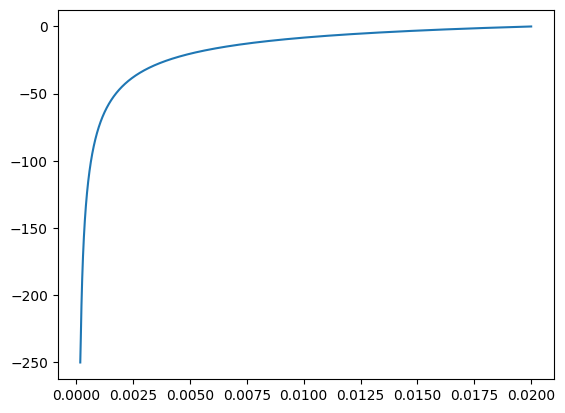

In [291]:
Qo = sol.y[0]
Mo = sol.y[1]
Ttot_o = sol.y[2]

plt.plot(Mo/Qo, np.arange(0,-250.2,-dz))


In [ ]:
Ei, Eo, Ea, Ep = entrainment(ui[midpoint], root, bi[midpoint], 0, rho_a, rho_i[midpoint], rho_r)
Ea + Eo - Ei + Ep ## dMo_dz

43.10461523839378
24.9314188737024
21.810599378609247
21.859942184309133
22.97894337856606
24.56148097996828
26.173848646873942
27.294076542224694
28.56123347164823
29.519980208945032
30.368751827850662
31.266126101461523
31.77480082423277
31.95608007660487
32.20185280555354
32.608502942287366
32.82159164255461
33.27657593187595
34.08502602503559
35.82431840883009
32.29498526808595


Text(0, 0.5, 'Depth z')

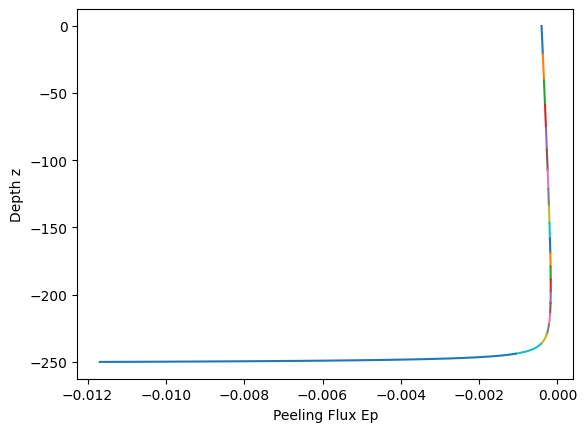

In [504]:
Qo_peel = np.zeros(Nz)
uo_peel = np.zeros(Nz)
Ttot_o_i = np.zeros(Nz)
Stot_o_i = np.zeros(Nz)
Qo_i = np.zeros(Nz)
Mo_i = np.zeros(Nz)
rho_o_i = np.zeros(Nz)
So_i = np.zeros(Nz)
To_i = np.zeros(Nz)
bo_i = np.zeros(Nz)
c4 = 0.3
stop = Nz - 1

while stop > 0:
    start = stop - int(bi[stop] / dz)
    if start < 0:
        start = 0
    midpoint = start + int((stop - start) / 2)

    # Integrate peeling flux over vertical region equal to inner plume width
    Qo_peel[midpoint] = -np.sum(E_p[start:stop])  * np.mean(bi[start:stop]) # multiply by dz to get flux in m^3/s if Ep in m^2/s

    dQo_dz = -np.sum(E_p[start:stop]) + np.sum(E_o[start:stop]) - np.sum(E_i[start:stop]) + np.sum(E_a[start:stop])
    print(dQo_dz)

    Qo_i[midpoint] = Qo_peel[midpoint] + c4 * np.mean(Qi[start:stop])
    Ttot_o_i[midpoint] = Qo_peel[midpoint] * np.mean(Ti[start:stop]) + c4 * np.mean(Qi[start:stop]) * T_a
    Stot_o_i[midpoint] = Qo_peel[midpoint] * np.mean(Si[start:stop]) + c4 * np.mean(Qi[start:stop]) * S_a

    To_i[midpoint] = Ttot_o_i[midpoint] / Qo_i[midpoint]
    So_i[midpoint] = Stot_o_i[midpoint] / Qo_i[midpoint]
    rho_o_i[midpoint] = rho_eq(So_i[midpoint], To_i[midpoint])

    # b_o = (Qo_peel[midpoint]**2 / (math.pi * Q_o * u_o) + np.mean(bi[start:stop])**2)**(1/2)

    # (Optional) Estimate outer plume velocity here if Qo_peel[midpoint] > 0:
    if Qo_i[midpoint] > 0:
        # Use eq 16 & 17 or relevant formula to compute uo_peel[midpoint]
        # Placeholder: uo_peel[midpoint] = some_function(Qo_peel[midpoint])

        uo_peel[midpoint] = brentq(uo_init, 0.00001, 0.1, args = (Qo_i[midpoint], rho_o_i[midpoint], np.mean(bi[start:stop])))
    else:
        uo_peel[midpoint] = 0.02
    
    Mo_i[midpoint] = Qo_i[midpoint] * uo_peel[midpoint]
    bo_i[midpoint] = Qo_i[midpoint] / np.sqrt(math.pi * Mo_i[midpoint])


    # Plot peeling flux over this segment (optional)
    plt.plot(Ep[start:stop], z[start:stop])
    stop = start
plt.xlabel('Peeling Flux Ep')
plt.ylabel('Depth z')


# Move upward by the length of the integrated region


In [495]:
E_a

array([0.68241495, 0.68208288, 0.68175085, ..., 0.41280411, 0.41301175,
       0.41321266])

In [421]:
To = To_i[np.where(To_i != 0)[0]]
So = So_i[np.where(So_i != 0)]
uo = uo_peel[np.where(uo_peel != 0)]
Qo = Qo_i[np.where(Qo_i != 0)]
Mo = Mo_i[np.where(Mo_i != 0)]
rho_o = rho_o_i[np.where(rho_o_i != 0)]
bo = bo_i[np.where(bo_i != 0)]

z_outer = np.linspace(-250, 0, len(So))
To_interp = interp1d(z_outer, To[::-1], fill_value="extrapolate")
So_interp = interp1d(z_outer, So[::-1], fill_value="extrapolate")
uo_interp = interp1d(z_outer, uo[::-1], fill_value="extrapolate")
Qo_interp = interp1d(z_outer, Qo[::-1], fill_value="extrapolate")
Mo_interp = interp1d(z_outer, Mo[::-1], fill_value="extrapolate")
rho_o = interp1d(z_outer, rho_o[::-1], fill_value="extrapolate")
bo_interp = interp1d(z_outer, bo[::-1], fill_value="extrapolate" )

In [259]:
T_a = 2
S_a = 34
y0_inner = np.array([40, 20, 0, 0])
sol_inner = solve_ivp(inner_plume, z_span, y0_inner, t_eval = zLevels, args=(0,0, T_a, S_a))

Qo_i = -sol.y[0][-1]
b_i = sol.y[0][-1] / np.sqrt(math.pi * sol.y[1][-1])

b_o = 1.1 * b_i
u_o = -0.1 * np.sqrt((b_o - b_i) * g * abs(rho_a - rho_o) / rho_r)
print(b_o); 
print(u_o)
Mo_i = math.pi * u_o**2 * (b_o**2 - b_i**2)
print(Mo_i)

To_i = sol_inner.y[2][-1]
So_i = sol_inner.y[3][-1]
y0_outer = np.array([Qo_i ,Mo_i, To_i, So_i])
sol_outer = solve_ivp(outer_plume, z_span[::-1], y0_outer, t_eval = zLevels[::-1], args=(sol_inner.y[0][-1],sol_inner.y[1][-1], sol_inner.y[2][-1], sol_inner.y[3][-1]))

Qi_after = sol_inner.y[0]
Qo_after = sol_outer.y[0]

Mi_after = sol_inner.y[1]
Mo_after = sol_outer.y[1]

nIters = 5

for i in range(0,nIters):

    Qi_before = Qi_after
    Qo_before = Qo_after

    Mi_before = Mi_after
    Mo_before = Mo_after

    y0_inner = np.array([40, 20, 0, 0])
    sol_inner = solve_ivp(inner_plume, z_span, y0_inner, t_eval = zLevels, args=(sol_outer.y[0][0], sol_outer.y[1][0], sol_outer.y[2][0], sol_outer.y[3][0]))

    Qo_i = -sol.y[0][-1]
    b_i = sol.y[0][-1] / np.sqrt(math.pi * sol.y[1][-1])
    b_o = 1.1 * b_i
    u_o = -0.1 * np.sqrt((b_o - b_i) * g * abs(rho_a - rho_o) / rho_r)
    Mo_i = math.pi * u_o**2 * (b_o**2 - b_i**2)
    To_i = sol_inner.y[2][-1]
    So_i = sol_inner.y[3][-1]

    y0_outer = np.array([Qo_i ,Mo_i, To_i, So_i])
    sol_outer = solve_ivp(outer_plume, z_span[::-1], y0_outer, t_eval = zLevels[::-1], args=(sol_inner.y[0][-1],sol_inner.y[1][-1], sol_inner.y[2][-1], sol_inner.y[3][-1]))

    Qi_after = sol_inner.y[0]
    Qo_after = sol_outer.y[0]

    Mi_after = sol_inner.y[1]
    Mo_after = sol_outer.y[1]

    error = np.nanmax([np.abs(Qi_before - Qi_after),
                    np.abs(Qo_before - Qo_after),
                    np.abs(Mi_before - Mi_after),
                    np.abs(Mo_before - Mo_after)])
    
    print(f"Iteration {i}, Error = {error}")

13.668478306363514
-0.04082369254542386
0.16976521267268022
Iteration 0, Error = 12161.323068912985
Iteration 1, Error = 1.5133527173602488
Iteration 2, Error = 0.004230650711150474
Iteration 3, Error = 0.005643587317749166
Iteration 4, Error = 0.004623753337980929


In [425]:
def inner_plume(z, y, Qo_interp, Mo_interp, To_interp, So_interp):

    Q_i = y[0]
    M_i = y[1]
    T_tot = y[2]
    S_tot = y[3]

    Q_o = Qo_interp(z)
    M_o = Mo_interp(z)
    T_o = To_interp(z)
    S_o = So_interp(z)

    T_i = T_tot / Q_i    # concentration (°C)
    S_i = S_tot / Q_i    # concentration (PSU)

    # velocities and width
    u_i = M_i / Q_i

    if Q_o == 0:
        u_o = 0.0
        b_o = 0.0
    else:
        u_o = M_o / Q_o
        b_o = (Q_o**2/(math.pi * M_o) + (Q_i/np.sqrt(math.pi*M_i))**2 )**0.5

    b_i = Q_i / np.sqrt(math.pi * M_i)  # protect sqrt arg

    # densities (ensure rho_eq expects PSU, degC)
    rho_i = rho_eq(S_i, T_i)

    # parameters (as in your code)
    chi = 0.0001
    rho_b = 1.204
    rho_a = rho_eq(34,2)
    rho_r = 1024.
    rho_m = chi * rho_b + (1-chi) * rho_i

    E_i, E_o, E_a, E_p = entrainment(z, u_i, u_o, b_i, b_o, rho_a, rho_m, rho_r)
    
    gamma = 1.1
    lam = 1.0
    g = 9.81
    
    # Buoyancy production term used in momentum eqn
    g_flux = math.pi * g * b_i**2 * (lam**2 * (rho_a - rho_m)) / (gamma * rho_r)

    # mass (Q) and momentum (M) tendencies
    dQidz = E_i - E_o - E_p
    dMidz = g_flux + E_i * u_o - E_o * u_i - E_p * u_i

    # Conservative salt & heat evolution: d(Q*S)/dz = E_i*S_o - E_o*S_i - E_p*S_i
    dS_tot_dz = E_i * S_o - E_o * S_i - E_p * S_i
    dT_tot_dz = E_i * T_o - E_o * T_i - E_p * T_i

    return np.array([dQidz, dMidz, dT_tot_dz, dS_tot_dz])

Initial Vol. Flux = 314.1592653589793. Initial Mom. Flux = 314.1592653589793.


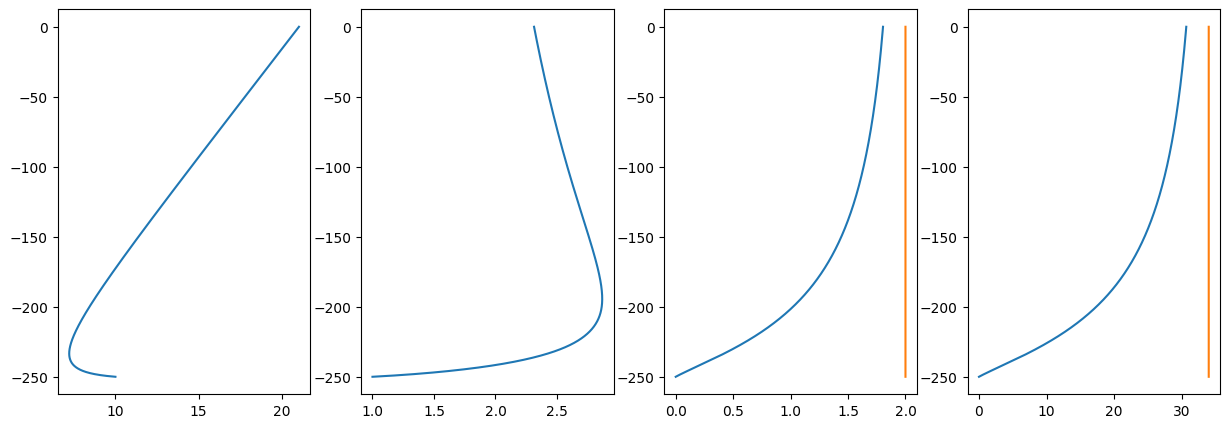

In [502]:
z_span = np.array([-250,0])
dz = 0.1
zLevels = np.arange(z_span[0], z_span[-1], dz)
Nz = len(zLevels)

bi_i = 10
ui_i = 1

Qi_i = bi_i**2 * ui_i * math.pi 
Mi_i = bi_i**2 * ui_i**2 * math.pi 
print(f"Initial Vol. Flux = {Qi_i}. Initial Mom. Flux = {Mi_i}.")
Ti_i = 0
Si_i = 0

Ttot_i = Ti_i * Qi_i
Stot_i = Si_i * Qi_i

y0_inner = np.array([Qi_i, Mi_i, Ttot_i, Stot_i])
T_a = 2
S_a = 34
# sol = solve_ivp(inner_plume, z_span, y0_inner, t_eval = zLevels, args=(Qo_interp, Mo_interp, To_interp, So_interp))

sol_outer = solve_ivp(
    inner_plume,
    (-250,0),  # backward in z
    y0_inner,
    method='RK45',
    max_step=1.0,
    args=(Qo_interp, Mo_interp, To_interp, So_interp),
    dense_output=True
)

Qi = sol.y[0]
Mi = sol.y[1]
Ti = sol.y[2] / Qi
Si = sol.y[3] / Qi
bi = Qi/np.sqrt(np.pi * Mi)
ui = Mi/Qi
rho_i = rho_eq(Si, Ti) 
z = sol.t

Ti_interp = interp1d(z, Ti[::-1], fill_value="extrapolate")
Si_interp = interp1d(z, Si[::-1], fill_value="extrapolate")
ui_interp = interp1d(z, ui[::-1], fill_value="extrapolate")
Qi_interp = interp1d(z, Qi[::-1], fill_value="extrapolate")
Mi_interp = interp1d(z, Mi[::-1], fill_value="extrapolate")
rho_i_interp = interp1d(z, rho_i[::-1], fill_value="extrapolate")
bi_interp = interp1d(z, bi[::-1], fill_value="extrapolate" )

E_i, E_o, E_a, E_p = entrainment(z, ui_interp, uo_interp, bi_interp, bo_interp, rho_a, rho_i_interp, rho_r)

fig, ax = plt.subplots(1,4, figsize = (15,5))

ax[0].plot(Qi/np.sqrt(np.pi * Mi), z)
ax[1].plot(Mi/Qi, z)
ax[2].plot(Ti, z)
ax[2].plot(np.ones(Nz) * T_a,z)
ax[3].plot(Si, z)
ax[3].plot(np.ones(Nz) * S_a, z)

In [491]:
dQo_dz = E_a + E_o - E_i - E_p
bad = np.where(dQo_dz < 0)[0]
for idx in bad:
    z_spot = z[idx]
    print(z_spot,
          "dQo_dz=", dQo_dz[idx],
          "E_o,E_a,E_p,E_i=", E_o[idx], E_a[idx], -E_p[idx], -E_i[idx],
          "Qo=", Qo_interp(z_spot),
          "b_i,b_o=", bi[idx], bo_interp(z_spot),
          "u_i,u_o=", ui[idx], uo_interp(z_spot))

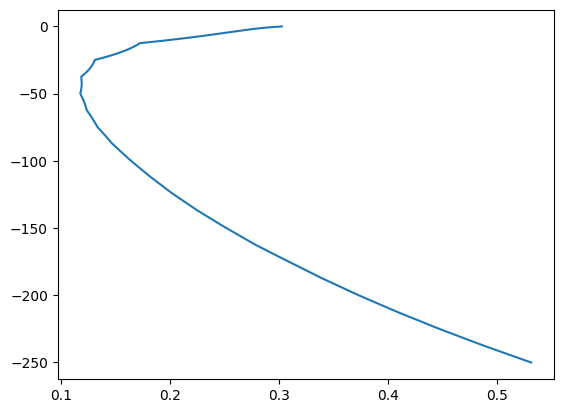

In [492]:
plt.plot(dQo_dz,z)

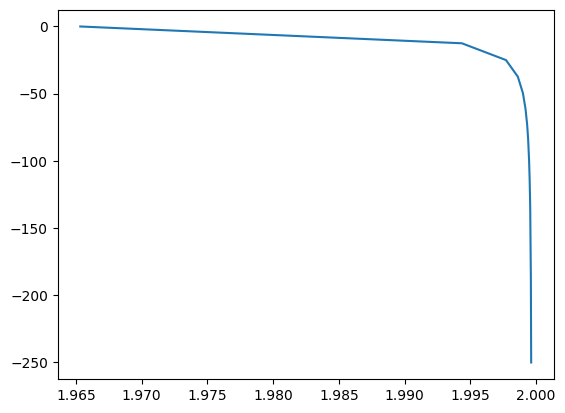

In [471]:
plt.plot(To_interp(np.linspace(-250,0,Nz)),z)

In [445]:
import numbers

In [446]:
isinstance(bo[0], numbers.Number)

True